In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [2]:
df = pd.read_csv('solar_system.csv')

In [4]:
print(df.shape) # shape of data set
print(df.head()) # first 5 rows
print(df.tail()) # last 5 rows
print(df.columns) # column names
print(df.index) # row names

(20, 11)
                Attribute Mercury  Venus  Earth   Moon   Mars Jupiter  Saturn  \
0          Mass (10^24kg)   0.330   4.87   5.97  0.073  0.642    1898     568   
1           Diameter (km)    4879  12104  12756   3475   6792  142984  120536   
2        Density (kg/m^3)    5429   5243   5514   3340   3934    1326     687   
3         Gravity (m/s^2)     3.7    8.9    9.8    1.6    3.7    23.1     9.0   
4  Escape Velocity (km/s)     4.3   10.4   11.2    2.4    5.0    59.5    35.5   

  Uranus Neptune   Pluto  
0   86.8     102  0.0130  
1  51118   49528    2376  
2   1270    1638    1850  
3    8.7    11.0     0.7  
4   21.3    23.5     1.3  
                  Attribute Mercury Venus Earth Moon  Mars  Jupiter   Saturn  \
15     Mean Temperature (C)     167   464    15  -20   -65     -110     -140   
16  Surface Pressure (bars)       0    92     1    0  0.01  Unknown  Unknown   
17          Number of Moons       0     0     1    0     2       95      274   
18             Ring Sy

In [26]:
orbital_period = df.iloc[10]
perihelion = df.iloc[8, 1:].astype(float)
aphelion   = df.iloc[9, 1:].astype(float)

### defining kepler's law terms

- perihelion: the point in orbit of an object when it's closest to the sun
- aphelion: the point in orbit when an object is farthest from the sun
- semi-major axis: half of the longest diameter of an ellipse

In [22]:
semi_major_axis = (perihelion + aphelion) / 2
semi_major_axis_list = semi_major_axis.tolist()

In [44]:
df.loc[len(df)] = ["Semi-Major Axis (AU)"] + semi_major_axis_list

print(df.shape) # shape of data set
print(df.columns) # column names
print(df.index) # row names

(22, 11)
Index(['Attribute', 'Mercury', 'Venus', 'Earth', 'Moon', 'Mars', 'Jupiter',
       'Saturn', 'Uranus', 'Neptune', 'Pluto'],
      dtype='object')
Index([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19,
       20, 21],
      dtype='int64')


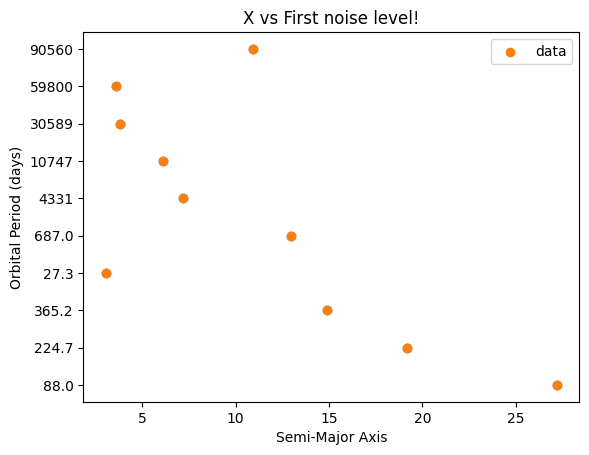

In [46]:
orbital_period = df.loc[df['Attribute'] == 'Orbital Period (days)'].iloc[0, 1:].tolist()

x = semi_major_axis_list
y = orbital_period

plt.scatter(x, y)
plt.scatter(x, y, label='data')
plt.xlabel("Semi-Major Axis")
plt.ylabel("Orbital Period (days)")
plt.title("X vs First noise level!")
plt.legend()
plt.show()


In [49]:
def keplers_third_law(a, m):
    return m * a ** 1.5

In [52]:
a = np.array(semi_major_axis_list, dtype=float)
T = np.array(orbital_period, dtype=float)

popt, pcov = curve_fit(keplers_third_law, a, T)
m_fit = popt[0]

print(f"Fitted model: T = {m_fit:.2f} * a^(3/2)")


Fitted model: T = 122.29 * a^(3/2)


In [54]:
T_model = keplers_third_law(a, m_fit)
chi2 = np.sum((T - T_model)**2)
reduced_chi2 = chi2 / (len(a) - 1)
print("Reduced chi-squared:", reduced_chi2)

Reduced chi-squared: 1369825298.2227135


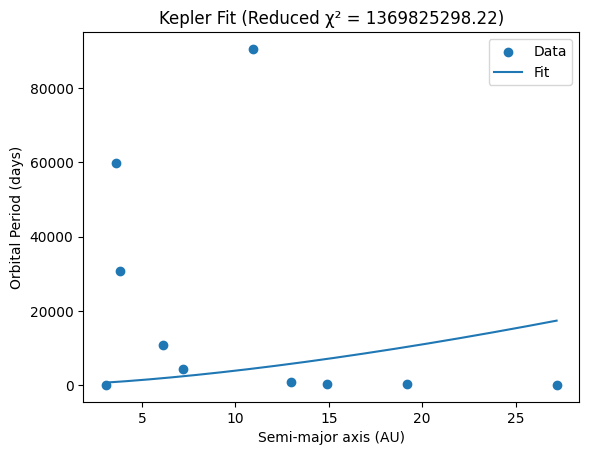

In [55]:
plt.scatter(a, T, label="Data")

a_fit = np.linspace(min(a), max(a), 200)
T_fit = keplers_third_law(a_fit, m_fit)
plt.plot(a_fit, T_fit, label="Fit")

plt.xlabel("Semi-major axis (AU)")
plt.ylabel("Orbital Period (days)")
plt.title(f"Kepler Fit (Reduced χ² = {reduced_chi2:.2f})")
plt.legend()

plt.show()

In [56]:
df.to_csv("kepler.csv", index=False)